In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [20]:
train_normal = []
train_pneumonia = []
test_normal = []
test_pneumonia = []
etiquetas = []

IMG_SIZE = (224, 224)  # Tamaño para todas las imágenes
rutas_pneumonia = tf.data.Dataset.list_files('./imagenes/test/PNEUMONIA/*.jpeg')
rutas_normal = tf.data.Dataset.list_files('./imagenes/test/NORMAL/*.jpeg')

# TODO Simplificar esto con una funcion y un map (como en el ejercicio 2)
for imgRoute in rutas_normal:
    img = tf.io.read_file(imgRoute)
    img_tensor = tf.image.decode_jpeg(img, channels = 3)
    img_resized = tf.image.resize(img_tensor, IMG_SIZE)  # Redimensionar a tamaño consistente
    # img_flattened = img_resized.flatten()  # Aplanar a 1D
    train_normal.append(img_resized)
    # Llenamos las etiquetas de 0 (normal) por cada foto de rayos-x sin pneumonia
    etiquetas.append(0)

train_normal_tensor = tf.convert_to_tensor(train_normal)
train_normal_df = tf.data.Dataset(train_normal_tensor)

for imgRoute in rutas_pneumonia:
    img = tf.io.read_file(imgRoute)
    img_tensor = tf.image.decode_jpeg(img, channels = 3)
    img_resized = tf.image.resize(img_tensor, IMG_SIZE)  # Redimensionar a tamaño consistente
    # img_flattened = img_resized.flatten()  # Aplanar a 1D
    train_pneumonia.append(img_resized)
    # Llenamos las etiquetas de 1 (pneumonia) por cada foto de rayos-x con pneumonia
    etiquetas.append(1)

train_normal_tensor = tf.convert_to_tensor(train_normal, dtype=tf.float32)
train_pneumonia_tensor = tf.convert_to_tensor(train_pneumonia, dtype=tf.float32)

train_normal_df = tf.data.Dataset.from_tensor_slices(train_normal_tensor)
train_pneumonia_df = tf.data.Dataset.from_tensor_slices(train_pneumonia_tensor)
etiquetas_df = tf.data.Dataset.from_tensor_slices(etiquetas)

dataset_imagenes = train_normal_df.concatenate(train_pneumonia_df)

dataset_final = tf.data.Dataset.zip((dataset_imagenes, etiquetas_df))

scaler = StandardScaler()
# X_normalizado = scaler.fit_transform(imagenes_train)
print(dataset_final.element_spec)
print('Total imágenes:', len(train_normal) + len(train_pneumonia))

TypeError: Can't instantiate abstract class DatasetV2 with abstract methods _inputs, element_spec

In [11]:
modelo = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='relu', input_shape=(10,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Config
IMG_SIZE = (90, 90)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# 1) Crear dataset con rutas + etiqueta
ds_normal = tf.data.Dataset.list_files('./imagenes/test/NORMAL/*.jpeg')
ds_normal = ds_normal.map(lambda p: (p, 0))

ds_pneumonia = tf.data.Dataset.list_files('./imagenes/test/PNEUMONIA/*.jpeg')
ds_pneumonia = ds_pneumonia.map(lambda p: (p, 1))

dataset = ds_normal.concatenate(ds_pneumonia)

# 2) Cargar y preparar imagen
def preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255
    return img, label

dataset = dataset.map(preprocess)

# 3) shuffle + batch + prefetch
dataset = dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(dataset.element_spec)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(90, 90, 3)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(dataset, epochs=10)


resultados = model.evaluate(dataset, return_dict=True)
print(resultados)

(TensorSpec(shape=(None, 90, 90, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 88, 88, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 44, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 42, 42, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 21, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,609 (5.42 MB)

 Trainable params: 1,420,609 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.6026 - loss: 0.6787
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.7228 - loss: 0.5342
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.8574 - loss: 0.3220
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.9022 - loss: 0.2830
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.8926 - loss: 0.2767
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9199 - loss: 0.2142
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.9183 - loss: 0.2086
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.9247 - loss: 0.2143
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9391 - loss: 0.1680
Epoch 10/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.9407 - loss: 0.1630
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9631 - loss: 0.1119
{'accuracy': 0.9631410241127014, 'loss': 0.11185235530138016}


In [ ]:
pred = model.predict(dataset)

from sklearn.metrics import confusion_matrix

y_pred = (pred >= 0.5).astype(int).flatten()

# 3. Obtener etiquetas verdaderas
y_true = []
for _, label in dataset.unbatch():
    y_true.append(int(label.numpy()))
y_true = np.array(y_true)

# 4. Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)
print("Matriz de confusión:\n", cm)

# TODO: Revisar ConfusionMatrixDisplay para mostrar la matriz de confusión de forma gráfica

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Matriz de confusión:
 [[ 96 138]
 [147 243]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━

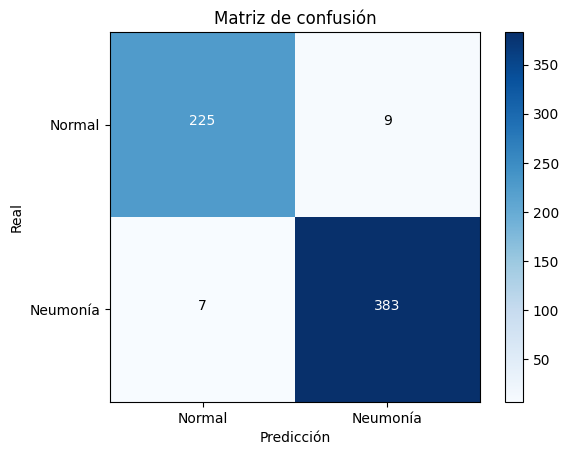

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import itertools

# 1. Obtener imágenes y etiquetas verdaderas del dataset
y_true = []
y_pred = []

for images, labels in dataset.unbatch():
    img = tf.expand_dims(images, axis=0)  # Añadir dimensión batch
    pred = model.predict(img)
    y_pred.append(1 if pred[0][0] >= 0.5 else 0)
    y_true.append(int(labels.numpy()))

print(y_pred)

# 2. Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# 3. (Opcional) Visualizar la matriz de confusión
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.colorbar()
plt.xticks([0,1], ["Normal", "Neumonía"])
plt.yticks([0,1], ["Normal", "Neumonía"])

# Añadir los números en la matriz
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > cm.max()/2 else "black")

plt.show()